In [1]:
import time
import datetime
import numpy as np
import xarray as xr
from urllib.request import urlopen

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cartopy.crs as ccrs
from shapely.geometry import Point
import matplotlib as mpl
from matplotlib.patches import Rectangle
import matplotlib.patches as mpatches
import geopandas as gpd

In [2]:
danecopath = "/Users/griffinberonio/Documents/Holloway_Group/Data/WashU_V6_NA/Dane_CO_V6NA01.CNNPM25_2021-2023_grids.gpkg"
danecodf = gpd.read_file(danecopath)
danecodf = danecodf.to_crs(epsg=4326)  # Ensure it's in WGS84 for plotting
print(type(danecodf))
danecodf.head()

<class 'geopandas.geodataframe.GeoDataFrame'>


,PM25,lat,lon,geometry
0,7.226562,42.715,-89.995003,"POLYGON ((-89.995 42.715, -89.985 42.715, -89...."
1,7.250000,42.715,-89.985001,"POLYGON ((-89.985 42.715, -89.975 42.715, -89...."
2,7.242188,42.715,-89.974998,"POLYGON ((-89.975 42.715, -89.965 42.715, -89...."
3,7.268229,42.715,-89.964996,"POLYGON ((-89.965 42.715, -89.955 42.715, -89...."
4,7.247396,42.715,-89.955002,"POLYGON ((-89.955 42.715, -89.945 42.715, -89...."


In [3]:
# Filtering for high concentration areas: (Using > 8 µg/m³ as a threshold for hotspots)
hotspots = danecodf[danecodf['PM25'] > 8].copy()
print(f"Number of hotspots identified: {len(hotspots)}")

Number of hotspots identified: 245


In [4]:
# importing us county shapefiles: 

counties = gpd.read_file("/Users/griffinberonio/Documents/Holloway_Group/Data/map_shapefiles/tl_2023_us_county/tl_2023_us_county.shp")
counties = counties.to_crs(epsg=4326)
danecounty = counties[counties['GEOID'] == '55025']


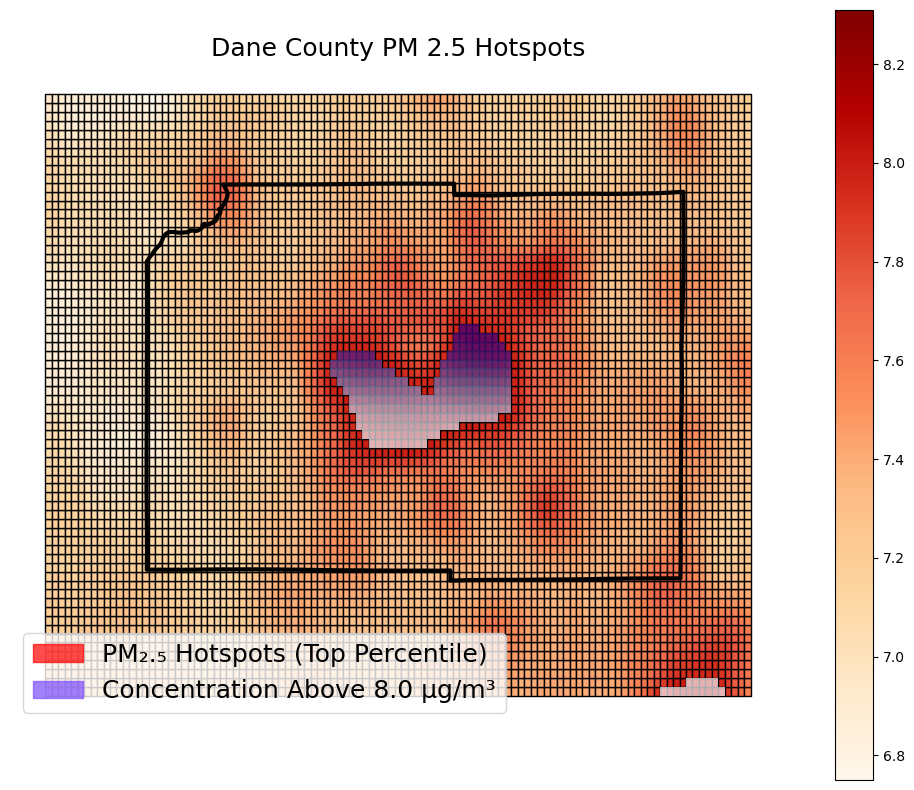

In [32]:
griddata = danecodf.copy()
hotplot = hotspots.copy()
countyplot = danecounty.copy()

countyoutline = countyplot.dissolve(by='COUNTYFP')

fig, ax = plt.subplots(figsize = (10,8))

danecodf.plot(column='PM25', ax=ax, legend=True, cmap='OrRd', edgecolor='k')
# countyoutline.plot(ax=ax, facecolor = False, color = 'black', linewidth=0.2)
countyoutline.boundary.plot(ax=ax, color='black', linewidth=3)
hotplot.plot(ax=ax, cmap="Purples", markersize=5, alpha=0.7, zorder=5)

legend_elements = [
    mpatches.Patch(color='red', alpha=0.7, label='PM₂.₅ Hotspots (Top Percentile)'),
    mpatches.Patch(color='#7C4DFF', alpha = 0.7, label = 'Concentration Above 8.0 µg/m³')]

ax.set_title('Dane County PM 2.5 Hotspots', fontsize = 18)
ax.legend(handles=legend_elements, loc='lower left', fontsize=18, framealpha=0.8)
ax.set_axis_off()

plt.tight_layout()
plt.show()


In [6]:
danecodf.head()

,PM25,lat,lon,geometry
0,7.226562,42.715,-89.995003,"POLYGON ((-89.995 42.715, -89.985 42.715, -89...."
1,7.250000,42.715,-89.985001,"POLYGON ((-89.985 42.715, -89.975 42.715, -89...."
2,7.242188,42.715,-89.974998,"POLYGON ((-89.975 42.715, -89.965 42.715, -89...."
3,7.268229,42.715,-89.964996,"POLYGON ((-89.965 42.715, -89.955 42.715, -89...."
4,7.247396,42.715,-89.955002,"POLYGON ((-89.955 42.715, -89.945 42.715, -89...."


Overlaying actual high concentration spots on Chandler's hotspots 

In [7]:
# Chandler's hotspot code:
grid_with_county = gpd.sjoin(
    danecodf[['PM25', 'geometry']],
    danecounty[['GEOID', 'geometry']],
    how='inner',
    predicate='within'
)[['PM25', 'GEOID', 'geometry']]

county_stats = (
    grid_with_county.groupby('GEOID')['PM25']
    .agg(
        county_mean='mean',
        county_std='std',
        county_min='min',
        county_max='max',
    )
    .reset_index()
)

# compute range (max - min)
county_stats['range'] = county_stats['county_max'] - county_stats['county_min']

# Step 3: exclude low-variability counties (valid counties > p10 of rel difference [max-min])
q10 = county_stats['range'].quantile(0.10)
print(f"Q10 range threshold: {q10:.3f}")
valid_counties = county_stats[county_stats['range'] >= q10]
print(f"Counties kept: {len(valid_counties)}/{len(county_stats)} ({len(valid_counties)/len(county_stats)*100:.1f}%)")

# Step 4: keep only valid counties
grid_with_county_valid = grid_with_county.merge(
    valid_counties[['GEOID']],
    on='GEOID',
    how='inner'
)

# Step 5: recompute stats AFTER filtering
county_stats_valid = (
    grid_with_county_valid.groupby('GEOID')['PM25']
    .agg(
        county_mean='mean',
        county_std='std',
        GWRPM25_90th=lambda x: x.quantile(0.90)
    )
    .reset_index()
)

grid_with_county_valid = grid_with_county_valid.merge(county_stats_valid, on='GEOID')

# Step 6: select hotspots (top 10% only)
top10_sd_hotspots = grid_with_county_valid[
    (grid_with_county_valid['PM25'] >= grid_with_county_valid['GWRPM25_90th']) &
    (~grid_with_county_valid['GEOID'].str.startswith(('02', '15')))
].copy()


Q10 range threshold: 1.456
Counties kept: 1/1 (100.0%)


In [8]:
# lets say the threshold is 7.952:
thresh = 8.2
conc_hotspots = top10_sd_hotspots[top10_sd_hotspots['PM25'] > thresh]
print(f'The number of concentration hotspots is: {conc_hotspots.shape[0]}')

conc_hotspots = conc_hotspots.copy()
print(f'The maximum concentration in the county is {(conc_hotspots['PM25'].max()):.2f}')


The number of concentration hotspots is: 50
The maximum concentration in the county is 8.31


In [9]:
# importing city of madison city limits shapefile:
citypath = '/Users/griffinberonio/Documents/Holloway_Group/Data/map_shapefiles/City_Limit/City_Limit.shp'
city = gpd.read_file(citypath)
city = city.to_crs(epsg=4326)

Plotting the Overlay: 

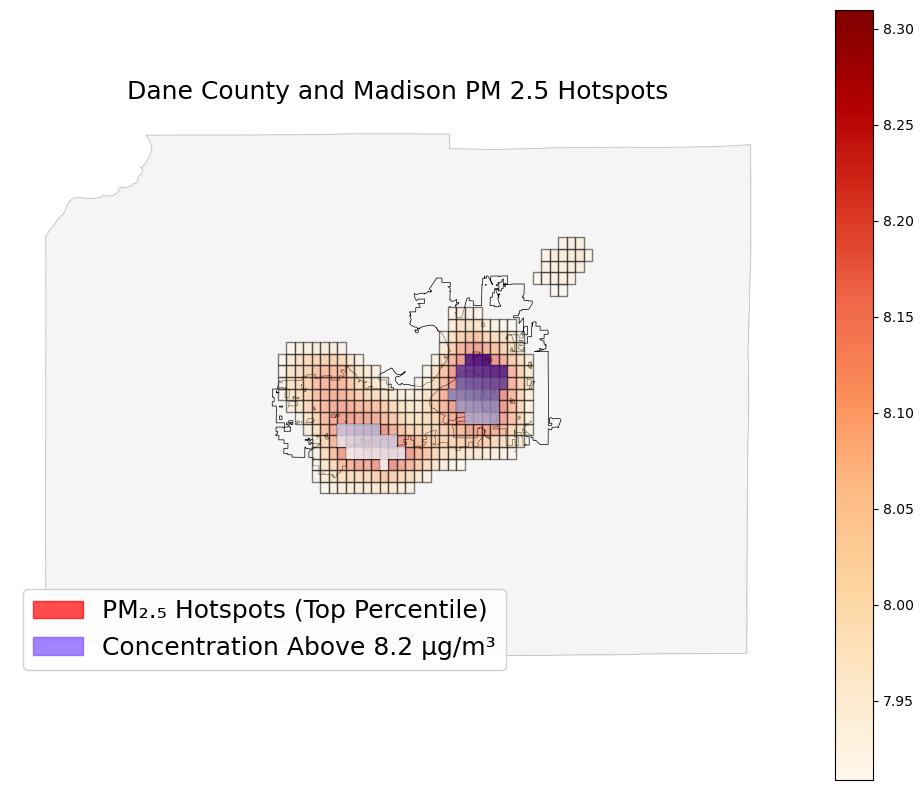

In [31]:
# Plotting
hotspot_plot = conc_hotspots.copy()
counties_plot = danecounty.copy()
chandlers = top10_sd_hotspots.copy()
cityplot = city.copy()

county_outline = counties_plot.dissolve(by='COUNTYFP', as_index=False)[['geometry']]

# Plot
fig, ax = plt.subplots(figsize=(10, 8))

counties_plot.plot(ax=ax, facecolor='#f5f5f5', edgecolor='#cccccc', linewidth=0.2, zorder=1)
cityplot.boundary.plot(ax=ax, facecolor='#f5f5f5', edgecolor='black', linewidth = 0.5, zorder=2)
chandlers.plot(ax=ax, column='PM25', legend=True, cmap='OrRd', edgecolor='k', alpha = 0.5, zorder =3)
county_outline.boundary.plot(ax=ax, color='#999999', linewidth=0.3, zorder=4)


# EPA monitors
if not hotspot_plot.empty:
    hotspot_plot.plot(ax=ax, cmap="Purples", markersize=5, alpha=0.8, zorder=5)

legend_elements = [
    mpatches.Patch(color='red', alpha=0.7, label='PM₂.₅ Hotspots (Top Percentile)'),
    mpatches.Patch(color='#7C4DFF', alpha = 0.7, label = 'Concentration Above 8.2 µg/m³')
    # plt.Line2D([0], [0], color='w', markerfacecolor='#7C4DFF', markersize=16, label='Concentration Above 8.2 µg/m³')
]

ax.legend(handles=legend_elements, loc='lower left', fontsize=18, framealpha=0.9)

ax.set_title('Dane County and Madison PM 2.5 Hotspots', fontsize=18)
ax.set_axis_off()

plt.tight_layout()
plt.savefig('hotspot_comparison_2021_2023.jpg', dpi=300, bbox_inches='tight')
plt.show()

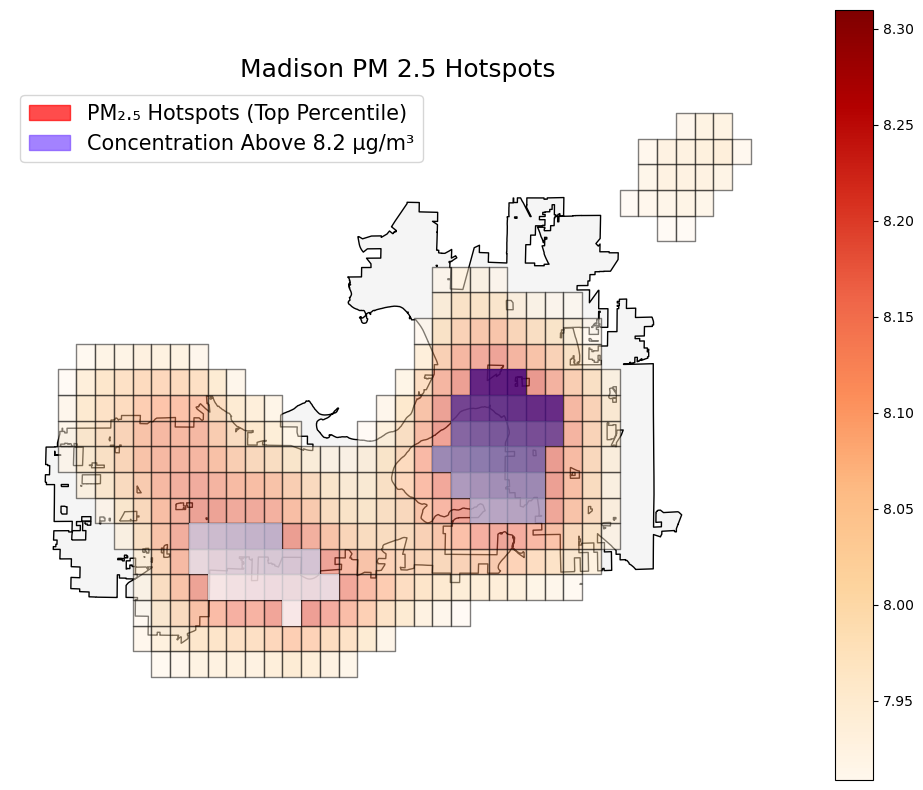

In [35]:
# Just the city of Madison:

# Plotting
hotspot_plot = conc_hotspots.copy()
counties_plot = danecounty.copy()
chandlers = top10_sd_hotspots.copy()
cityplot = city.copy()

county_outline = counties_plot.dissolve(by='COUNTYFP', as_index=False)[['geometry']]

# Plot
fig, ax = plt.subplots(figsize=(10, 8))

# counties_plot.plot(ax=ax, facecolor='#f5f5f5', edgecolor='#cccccc', linewidth=0.2, zorder=1)
cityplot.boundary.plot(ax=ax, facecolor='#f5f5f5', edgecolor='black', linewidth = 1, zorder=2)
chandlers.plot(ax=ax, column='PM25', legend=True, cmap='OrRd', edgecolor='k', alpha = 0.5, zorder =3)
# county_outline.boundary.plot(ax=ax, color='#999999', linewidth=0.3, zorder=4)


# EPA monitors
if not hotspot_plot.empty:
    hotspot_plot.plot(ax=ax, cmap="Purples", markersize=5, alpha=0.8, zorder=5)

legend_elements = [
    mpatches.Patch(color='red', alpha=0.7, label='PM₂.₅ Hotspots (Top Percentile)'),
    mpatches.Patch(color='#7C4DFF', alpha = 0.7, label = 'Concentration Above 8.2 µg/m³')
    # plt.Line2D([0], [0], color='w', markerfacecolor='#7C4DFF', markersize=16, label='Concentration Above 8.2 µg/m³')
]

ax.legend(handles=legend_elements, loc='upper left', fontsize=15, framealpha=0.8)

ax.set_axis_off()
ax.set_title('Madison PM 2.5 Hotspots', fontsize=18)
plt.tight_layout()
plt.savefig('Madison_hotspot_comparison_2021_2023.jpg', dpi=300, bbox_inches='tight')
plt.show()